# CREATE FIGURE 3D-E AND SUPPLEMENTARY FIGURE 7B, D-G PANELS
## last updated: 06.12.26

In [1]:
%run "ecDNAInspector_functions.ipynb"

/Users/spribus/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [7]:
import numpy as np
import pandas as pd
import ast
from itertools import combinations
from scipy.stats import mannwhitneyu
import random
import os

In [3]:
# load path to cycle-level data table with confidence assignment included
cycle_level_data_table = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_table)
cohort_df["Cycle Regions List"] = cohort_df["Cycle Regions List"].apply(ast.literal_eval)

In [4]:
# load subtype information for all samples
subtype_info = 'full_tool_testing/BCarc_eniclust.csv'
subtype_df = pd.read_csv(subtype_info)
merged_df = pd.merge(cohort_df, subtype_df, on="Sample", how="left")

In [5]:
# IC6-specific info
ic6_chr = '8'
ic6_df = merged_df[merged_df["ENiClust"] == 'ic6']

In [8]:
# load UCD12 short-read-based cycles
UCD12_SR_cycle_file = 'cell_line_validation/UCD12_SR_amplicon2_cycles.txt'
convert_single_cycle_file(UCD12_SR_cycle_file, 'cell_line_validation', 4.0, "all", "UCD12_SR", "2")
UCD12_SR_processed_cycle_file = 'cell_line_validation/UCD12_SR_liftover_processed_amplicon2_cycles.txt'

UCD12_cycle_df_list = []

cycle_nums = parse_cycle_file_for_cycle_nums(UCD12_SR_processed_cycle_file)

for cycle in cycle_nums:
    cycle_region_list = parse_cycle_file_for_cycle_region_list(UCD12_SR_processed_cycle_file, cycle)
    cycle_list = ['UCD12', '2', cycle, cycle_region_list]
    UCD12_cycle_df_list.append(cycle_list)

UCD12_SR_df = pd.DataFrame(UCD12_cycle_df_list, columns=["Sample", "Amplicon", "Cycle", "Cycle Regions List"])

In [9]:
# filter to include only cycles with the IC6 cytoband chromosome
UCD12_SR_filt_df = UCD12_SR_df[UCD12_SR_df["Cycle Regions List"].apply(lambda x: any(str(t[0]) == ic6_chr for t in x))]

In [10]:
# load UCD65 short-read-based cycles
UCD65_SR_cycle_file = 'cell_line_validation/UCD65_SR_amplicon1_cycles.txt'
convert_single_cycle_file(UCD65_SR_cycle_file, 'cell_line_validation', 4.0, "all", "UCD65_SR", "1")
UCD65_SR_processed_cycle_file = 'cell_line_validation/UCD65_SR_liftover_processed_amplicon1_cycles.txt'

UCD65_cycle_df_list = []

cycle_nums = parse_cycle_file_for_cycle_nums(UCD65_SR_processed_cycle_file)

for cycle in cycle_nums:
    cycle_region_list = parse_cycle_file_for_cycle_region_list(UCD65_SR_processed_cycle_file, cycle)
    cycle_list = ['UCD65', '1', cycle, cycle_region_list]
    UCD65_cycle_df_list.append(cycle_list)

UCD65_SR_df = pd.DataFrame(UCD65_cycle_df_list, columns=["Sample", "Amplicon", "Cycle", "Cycle Regions List"])

In [11]:
# filter to include only cycles with the IC6 cytoband chromosome
UCD65_SR_filt_df = UCD65_SR_df[UCD65_SR_df["Cycle Regions List"].apply(lambda x: any(str(t[0]) == ic6_chr for t in x))]

In [12]:
# load SKBR3 short-read-based cycles
SKBR3prt_SR_cycle_file = 'cell_line_validation/SKBR3prt_SR_amplicon2_cycles.txt'
convert_single_cycle_file(SKBR3prt_SR_cycle_file, 'cell_line_validation', 4.0, "all", "SKBR3prt_SR", "2")
SKBR3prt_SR_processed_cycle_file = 'cell_line_validation/SKBR3prt_SR_liftover_processed_amplicon2_cycles.txt'

SKBR3prt_cycle_df_list = []

cycle_nums = parse_cycle_file_for_cycle_nums(SKBR3prt_SR_processed_cycle_file)

for cycle in cycle_nums:
    cycle_region_list = parse_cycle_file_for_cycle_region_list(SKBR3prt_SR_processed_cycle_file, cycle)
    cycle_list = ['SKBR3prt', '2', cycle, cycle_region_list]
    SKBR3prt_cycle_df_list.append(cycle_list)

SKBR3prt_cycle_df = pd.DataFrame(SKBR3prt_cycle_df_list, columns=["Sample", "Amplicon", "Cycle", "Cycle Regions List"])

In [13]:
# load UCD12 long-read-based cycles
UCD12_LR_cycle_file = 'cell_line_validation/UCD12_LR_amplicon7_cycles.txt'
convert_single_cycle_file(UCD12_LR_cycle_file, 'cell_line_validation', 4.0, "all", "UCD12_LR", "7")
UCD12_LR_processed_cycle_file = 'cell_line_validation/UCD12_LR_liftover_processed_amplicon7_cycles.txt'

UCD12_cycle_df_list = []

cycle_nums = parse_cycle_file_for_cycle_nums(UCD12_LR_processed_cycle_file)

for cycle in cycle_nums:
    cycle_region_list = parse_cycle_file_for_cycle_region_list(UCD12_LR_processed_cycle_file, cycle)
    cycle_list = ['UCD12', '7', cycle, cycle_region_list]
    UCD12_cycle_df_list.append(cycle_list)

UCD12_LR_df = pd.DataFrame(UCD12_cycle_df_list, columns=["Sample", "Amplicon", "Cycle", "Cycle Regions List"])

In [14]:
# filter to include only cycles with the IC6 cytoband chromosome
UCD12_LR_filt_df = UCD12_LR_df[UCD12_LR_df["Cycle Regions List"].apply(lambda x: any(str(t[0]) == ic6_chr for t in x))]

In [15]:
# load UCD65 long-read-based cycles
UCD65_LR_cycle_file = 'cell_line_validation/UCD65_LR_amplicon2_cycles.txt'
convert_single_cycle_file(UCD65_LR_cycle_file, 'cell_line_validation', 4.0, "all", "UCD65_LR", "2")
UCD65_LR_processed_cycle_file = 'cell_line_validation/UCD65_LR_liftover_processed_amplicon2_cycles.txt'

UCD65_cycle_df_list = []

cycle_nums = parse_cycle_file_for_cycle_nums(UCD65_LR_processed_cycle_file)

for cycle in cycle_nums:
    cycle_region_list = parse_cycle_file_for_cycle_region_list(UCD65_LR_processed_cycle_file, cycle)
    cycle_list = ['UCD65', '2', cycle, cycle_region_list]
    UCD65_cycle_df_list.append(cycle_list)

UCD65_LR_df = pd.DataFrame(UCD65_cycle_df_list, columns=["Sample", "Amplicon", "Cycle", "Cycle Regions List"])

In [16]:
# filter to include only cycles with the IC6 cytoband chromosome
UCD65_LR_filt_df = UCD65_LR_df[UCD65_LR_df["Cycle Regions List"].apply(lambda x: any(str(t[0]) == ic6_chr for t in x))]

In [17]:
# get merged UCD12 SR & LR regions

In [18]:
def overlap(region1, region2):
    chr1, start1_og, end1_og = region1
    chr2, start2_og, end2_og = region2

    start1 = min(start1_og, end1_og)
    end1 = max(start1_og, end1_og)
    start2 = min(start2_og, end2_og)
    end2 = max(start2_og, end2_og)
    
    if chr1 == chr2:
        if max(start1, start2) <= min(end1, end2):
            overlap_start = max(start1, start2)
            overlap_end = min(end1, end2)
            return (chr1, overlap_start, overlap_end)
    return None

In [19]:
UCD12_SR_LR_intersect = []

for i, row1 in UCD12_SR_filt_df.iterrows():
    for j, row2 in UCD12_LR_filt_df.iterrows():
        for region1 in row1['Cycle Regions List']:
            for region2 in row2['Cycle Regions List']:
                common_region = overlap(region1, region2)
                if common_region:
                    UCD12_SR_LR_intersect.append(common_region)

In [20]:
UCD12_SR_LR_intersect.sort(key=lambda x: (x[0], x[1]))

UCD12_SR_LR_final = []
for region in UCD12_SR_LR_intersect:
    if not UCD12_SR_LR_final:
        UCD12_SR_LR_final.append(region)
    else:
        last_region = UCD12_SR_LR_final[-1]
        if last_region[0] == region[0] and last_region[2] >= region[1]:
            UCD12_SR_LR_final[-1] = (last_region[0], last_region[1], max(last_region[2], region[2]))
        else:
            UCD12_SR_LR_final.append(region)

In [21]:
# get merged UCD65 SR & LR regions

In [22]:
UCD65_SR_LR_intersect = []

for i, row1 in UCD65_SR_filt_df.iterrows():
    for j, row2 in UCD65_LR_filt_df.iterrows():
        for region1 in row1['Cycle Regions List']:
            for region2 in row2['Cycle Regions List']:
                common_region = overlap(region1, region2)
                if common_region:
                    UCD65_SR_LR_intersect.append(common_region)

In [23]:
UCD65_SR_LR_intersect.sort(key=lambda x: (x[0], x[1]))

UCD65_SR_LR_final = []
for region in UCD65_SR_LR_intersect:
    if not UCD65_SR_LR_final:
        UCD65_SR_LR_final.append(region)
    else:
        last_region = UCD65_SR_LR_final[-1]
        if last_region[0] == region[0] and last_region[2] >= region[1]:
            UCD65_SR_LR_final[-1] = (last_region[0], last_region[1], max(last_region[2], region[2]))
        else:
            UCD65_SR_LR_final.append(region)

### FIGURE 3D&E, SUPP. FIG 8D&E

In [23]:
# compute basepair Jaccard index of each IC6 cycle with the merged UCD12 ecDNA regions

In [28]:
def convert_cycle_regions_list_to_dict(cycle_regions_list):
    cycle_regions_dict = {}
    for chrom, start, end in cycle_regions_list:
        if chrom not in cycle_regions_dict:
            cycle_regions_dict[chrom] = []
        cycle_regions_dict[chrom].append((start, end))
    return cycle_regions_dict

In [29]:
UCD12_ic6_jaccard_df_list = []

for _, row in ic6_df.iterrows():

    UCD12_region_dict = convert_cycle_regions_list_to_dict(UCD12_SR_LR_final)
    IC6_region_dict = convert_cycle_regions_list_to_dict(row["Cycle Regions List"])

    jaccard = calc_bp_jaccard(UCD12_region_dict, IC6_region_dict)

    UCD12_ic6_jaccard_df_list.append({
        'Cell Line': 'UCD12',
        'Sample': row["Sample"],
        'Sample Amplicon': row['Amplicon'],
        'Sample Cycle': row['Cycle'],
        'Sample Confidence': row["Confidence"],
        'Jaccard': jaccard
        })

UCD12_ic6_jaccard_df = pd.DataFrame(UCD12_ic6_jaccard_df_list)

In [30]:
UCD12_ic6_jaccard_df['Sample Confidence'] = UCD12_ic6_jaccard_df['Sample Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})

In [ ]:
# compute basepair Jaccard index of each IC6 cycle with the merged UCD65 ecDNA regions

In [32]:
UCD65_ic6_jaccard_df_list = []

for _, row in ic6_df.iterrows():

    UCD65_region_dict = convert_cycle_regions_list_to_dict(UCD65_SR_LR_final)
    IC6_region_dict = convert_cycle_regions_list_to_dict(row["Cycle Regions List"])

    jaccard = calc_bp_jaccard(UCD65_region_dict, IC6_region_dict)

    UCD65_ic6_jaccard_df_list.append({
        'Cell Line': 'UCD65',
        'Sample': row["Sample"],
        'Sample Amplicon': row['Amplicon'],
        'Sample Cycle': row['Cycle'],
        'Sample Confidence': row["Confidence"],
        'Jaccard': jaccard
        })

UCD65_ic6_jaccard_df = pd.DataFrame(UCD65_ic6_jaccard_df_list)

In [33]:
UCD65_ic6_jaccard_df['Sample Confidence'] = UCD65_ic6_jaccard_df['Sample Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})

In [34]:
# compute basepair Jaccard index of each IC6 cycle with each SKBR3 cycle

In [35]:
SKBR3_ic6_jaccard_df_list = []

for _, row1 in SKBR3prt_cycle_df.iterrows():
    
    for _, row2 in ic6_df.iterrows():
    
        SKBR3_region_dict = convert_cycle_regions_list_to_dict(row1["Cycle Regions List"])
        IC6_region_dict = convert_cycle_regions_list_to_dict(row2["Cycle Regions List"])

        jaccard = calc_bp_jaccard(SKBR3_region_dict, IC6_region_dict)

        SKBR3_ic6_jaccard_df_list.append({
            'Cell Line': 'SKBR3',
            'Cell Line Amplicon': row1["Amplicon"],
            'Cell Line Cycle': row1["Cycle"],
            'Sample': row2["Sample"],
            'Sample Amplicon': row2['Amplicon'],
            'Sample Cycle': row2['Cycle'],
            'Sample Confidence': row2["Confidence"],
            'Jaccard': jaccard
            })

SKBR3_ic6_jaccard_df = pd.DataFrame(SKBR3_ic6_jaccard_df_list)

In [36]:
SKBR3_ic6_jaccard_df['Sample Confidence'] = SKBR3_ic6_jaccard_df['Sample Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})

In [37]:
# compute intra-IC6 basepair Jaccard indices

In [38]:
ic6_jaccs = []

for (sample1, amp1, cycle1), (sample2, amp2, cycle2) in combinations(ic6_df[['Sample', 'Amplicon', 'Cycle']].values, 2):

    if sample1 != sample2:
        row1 = ic6_df[(ic6_df['Sample'] == sample1) & (ic6_df['Amplicon'] == amp1) & (ic6_df['Cycle'] == cycle1)]
        row2 = ic6_df[(ic6_df['Sample'] == sample2) & (ic6_df['Amplicon'] == amp2) & (ic6_df['Cycle'] == cycle2)]
        
        regions1 = row1['Cycle Regions List'].values[0]
        regions2 = row2['Cycle Regions List'].values[0]
        
        regions1_dict = convert_cycle_regions_list_to_dict(regions1)
        regions2_dict = convert_cycle_regions_list_to_dict(regions2)

        jaccard = calc_bp_jaccard(regions1_dict, regions2_dict)
        
        ic6_jaccs.append({
            'Sample1': sample1,
            'Amp1': amp1,
            'Cycle1': cycle1,
            'Sample2': sample2,
            'Amp2': amp2,
            'Cycle2': cycle2,
            'BP Jaccard': jaccard,
        })

ic6_jaccs_df = pd.DataFrame(ic6_jaccs)

In [39]:
ic6_jaccs_df_reshaped = pd.concat([
    ic6_jaccs_df[['Sample1', 'Amp1', 'Cycle1', 'BP Jaccard']].rename(columns={'Sample1': 'Sample', 'Amp1': 'Amplicon', 'Cycle1': 'Cycle'}),
    ic6_jaccs_df[['Sample2', 'Amp2', 'Cycle2', 'BP Jaccard']].rename(columns={'Sample2': 'Sample', 'Amp2': 'Amplicon', 'Cycle2': 'Cycle'})
])

ic6_max_jaccs_df = ic6_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['BP Jaccard'].max().reset_index()

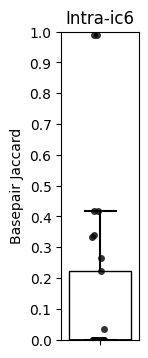

In [40]:
data_df = ic6_max_jaccs_df

plt.figure(figsize=(1, 4))

sns.boxplot(y='BP Jaccard', data=data_df, whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0))

sns.stripplot(y='BP Jaccard', data=data_df, color='black', alpha=0.8, jitter=True)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.title('Intra-ic6')
plt.xlabel('')
plt.ylabel('Basepair Jaccard')

plt.show()

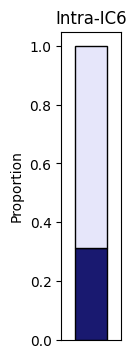

In [57]:
ic6_max_jaccs_df['Jaccard_Zero'] = (ic6_max_jaccs_df['BP Jaccard'] == 0).astype(int)

proportions = ic6_max_jaccs_df['Jaccard_Zero'].value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(1, 4))

ax.bar([''], [proportions[0]], color='midnightblue', edgecolor='black', label='Non-zero')
ax.bar([''], [proportions[1]], bottom=[proportions[0]], color='lavender', edgecolor='black', label='Zero')

plt.title('Intra-IC6')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks([]) 
plt.ylim(0, 1)
plt.xlim(-0.75, 0.75)
plt.ylim(0, 1.05)
plt.subplots_adjust(left=0.2, right=0.8)

plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/4087822472.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD12_ic6_jaccard_df, palette="Set3", whis=1.5,


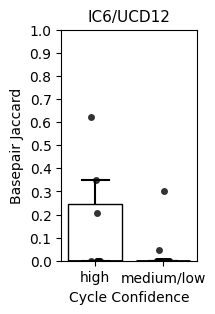

In [41]:
x_order = ['high', 'medium/low']

plt.figure(figsize=(1.75, 3))

sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD12_ic6_jaccard_df, palette="Set3", whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
            order=x_order)

sns.stripplot(x='Sample Confidence', y='Jaccard', data=UCD12_ic6_jaccard_df, color='black', alpha=0.8, jitter=True, order=x_order)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.xlabel("Cycle Confidence")
plt.ylabel('Basepair Jaccard')

plt.title(f'IC6/UCD12', fontsize=11)

plt.show()

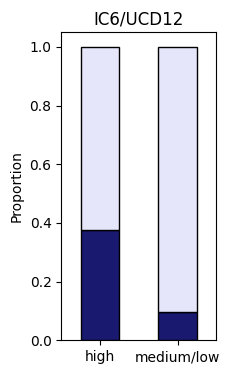

In [59]:
UCD12_ic6_jaccard_df['Jaccard_Zero'] = (UCD12_ic6_jaccard_df['Jaccard'] == 0).astype(int)

proportions = UCD12_ic6_jaccard_df.groupby('Sample Confidence')['Jaccard_Zero'].value_counts(normalize=True).unstack(fill_value=0)

proportions = proportions.loc[x_order]

fig, ax = plt.subplots(figsize=(2, 4))
ax = proportions.plot(kind='bar', stacked=True, color=['midnightblue', 'lavender'], edgecolor='black', ax=ax)

plt.title('IC6/UCD12')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
ax.legend_.remove()
plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/4292190964.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD65_ic6_jaccard_df, palette="Set3", whis=1.5,


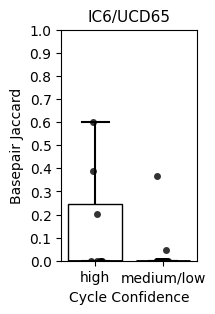

In [42]:
x_order = ['high', 'medium/low']

plt.figure(figsize=(1.75, 3))

sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD65_ic6_jaccard_df, palette="Set3", whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
            order=x_order)

sns.stripplot(x='Sample Confidence', y='Jaccard', data=UCD65_ic6_jaccard_df, color='black', alpha=0.8, jitter=True, order=x_order)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.xlabel("Cycle Confidence")
plt.ylabel('Basepair Jaccard')

plt.title(f'IC6/UCD65', fontsize=11)

plt.show()

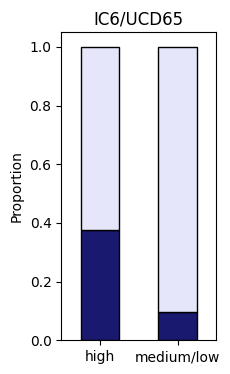

In [60]:
UCD65_ic6_jaccard_df['Jaccard_Zero'] = (UCD65_ic6_jaccard_df['Jaccard'] == 0).astype(int)

proportions = UCD65_ic6_jaccard_df.groupby('Sample Confidence')['Jaccard_Zero'].value_counts(normalize=True).unstack(fill_value=0)

proportions = proportions.loc[x_order]

fig, ax = plt.subplots(figsize=(2, 4))
ax = proportions.plot(kind='bar', stacked=True, color=['midnightblue', 'lavender'], edgecolor='black', ax=ax)

plt.title('IC6/UCD65')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
ax.legend_.remove()
plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/380066846.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sample Confidence', y='Jaccard', data=SKBR3_ic6_jaccard_df, palette="Set3", whis=1.5,


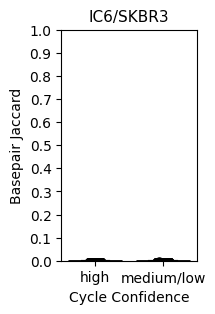

In [43]:
x_order = ['high', 'medium/low']

plt.figure(figsize=(1.75, 3))

sns.boxplot(x='Sample Confidence', y='Jaccard', data=SKBR3_ic6_jaccard_df, palette="Set3", whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
            order=x_order)

sns.stripplot(x='Sample Confidence', y='Jaccard', data=SKBR3_ic6_jaccard_df, color='black', alpha=0.8, jitter=True, order=x_order)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.xlabel("Cycle Confidence")
plt.ylabel('Basepair Jaccard')

plt.title(f'IC6/SKBR3', fontsize=11)

plt.show()

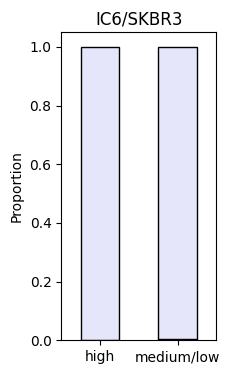

In [61]:
SKBR3_ic6_jaccard_df['Jaccard_Zero'] = (SKBR3_ic6_jaccard_df['Jaccard'] == 0).astype(int)

proportions = SKBR3_ic6_jaccard_df.groupby('Sample Confidence')['Jaccard_Zero'].value_counts(normalize=True).unstack(fill_value=0)

proportions = proportions.loc[x_order]

fig, ax = plt.subplots(figsize=(2, 4))
ax = proportions.plot(kind='bar', stacked=True, color=['midnightblue', 'lavender'], edgecolor='black', ax=ax)

plt.title('IC6/SKBR3')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
ax.legend_.remove()
plt.show()

In [44]:
group1 = ic6_max_jaccs_df['BP Jaccard']
group2 = UCD12_ic6_jaccard_df[UCD12_ic6_jaccard_df["Sample Confidence"] == "high"]['Jaccard']
stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
n1 = len(group1)
n2 = len(group2)

# calculate Rank-Biserial correlation for effect size
rank_biserial = (2 * (stat - n1 * n2 / 2)) / (n1 * n2)

print("p = " + str(p_value))
print("RB = " + str(rank_biserial))

p = 0.7730619108438604
RB = -0.0603448275862069


In [45]:
group1 = UCD12_ic6_jaccard_df[UCD12_ic6_jaccard_df["Sample Confidence"] == "high"]['Jaccard']
group2 = UCD12_ic6_jaccard_df[UCD12_ic6_jaccard_df["Sample Confidence"] == "medium/low"]['Jaccard']
stat, p_value = mannwhitneyu(group1, group2, alternative='greater')
n1 = len(group1)
n2 = len(group2)

# calculate Rank-Biserial correlation for effect size
rank_biserial = (2 * (stat - n1 * n2 / 2)) / (n1 * n2)

print("p = " + str(p_value))
print("RB = " + str(rank_biserial))

p = 0.031957501903877354
RB = 0.30357142857142855


In [46]:
group1 = ic6_max_jaccs_df['BP Jaccard']
group2 = UCD65_ic6_jaccard_df[UCD65_ic6_jaccard_df["Sample Confidence"] == "high"]['Jaccard']
stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
n1 = len(group1)
n2 = len(group2)

# calculate Rank-Biserial correlation for effect size
rank_biserial = (2 * (stat - n1 * n2 / 2)) / (n1 * n2)

print("p = " + str(p_value))
print("RB = " + str(rank_biserial))

p = 0.7730619108438604
RB = -0.0603448275862069


In [47]:
group1 = UCD65_ic6_jaccard_df[UCD65_ic6_jaccard_df["Sample Confidence"] == "high"]['Jaccard']
group2 = UCD65_ic6_jaccard_df[UCD65_ic6_jaccard_df["Sample Confidence"] == "medium/low"]['Jaccard']
stat, p_value = mannwhitneyu(group1, group2, alternative='greater')
n1 = len(group1)
n2 = len(group2)

# calculate Rank-Biserial correlation for effect size
rank_biserial = (2 * (stat - n1 * n2 / 2)) / (n1 * n2)

print("p = " + str(p_value))
print("RB = " + str(rank_biserial))

p = 0.031957501903877354
RB = 0.30357142857142855


### SUPP. FIG. 8F&G

In [52]:
# IC5-specific info
ic5_chr = '17'
ic5_df = merged_df[merged_df["ENiClust"] == 'ic5']

In [54]:
# filter to include only cycles with the IC5 cytoband chromosome
SKBR3prt_cycle_filt_df = SKBR3prt_cycle_df[SKBR3prt_cycle_df["Cycle Regions List"].apply(lambda x: any(str(t[0]) == ic5_chr for t in x))]

In [55]:
# compute intra-IC5 basepair Jaccard indices

In [62]:
ic5_jaccs = []

for (sample1, amp1, cycle1), (sample2, amp2, cycle2) in combinations(ic5_df[['Sample', 'Amplicon', 'Cycle']].values, 2):

    if sample1 != sample2:
        row1 = ic5_df[(ic5_df['Sample'] == sample1) & (ic5_df['Amplicon'] == amp1) & (ic5_df['Cycle'] == cycle1)]
        row2 = ic5_df[(ic5_df['Sample'] == sample2) & (ic5_df['Amplicon'] == amp2) & (ic5_df['Cycle'] == cycle2)]
        
        regions1 = row1['Cycle Regions List'].values[0]
        regions2 = row2['Cycle Regions List'].values[0]
        
        regions1_dict = convert_cycle_regions_list_to_dict(regions1)
        regions2_dict = convert_cycle_regions_list_to_dict(regions2)

        jaccard = calc_bp_jaccard(regions1_dict, regions2_dict)
        
        ic5_jaccs.append({
            'Sample1': sample1,
            'Amp1': amp1,
            'Cycle1': cycle1,
            'Sample2': sample2,
            'Amp2': amp2,
            'Cycle2': cycle2,
            'BP Jaccard': jaccard,
        })

ic5_jaccs_df = pd.DataFrame(ic5_jaccs)

In [63]:
ic5_jaccs_df_reshaped = pd.concat([
    ic5_jaccs_df[['Sample1', 'Amp1', 'Cycle1', 'BP Jaccard']].rename(columns={'Sample1': 'Sample', 'Amp1': 'Amplicon', 'Cycle1': 'Cycle'}),
    ic5_jaccs_df[['Sample2', 'Amp2', 'Cycle2', 'BP Jaccard']].rename(columns={'Sample2': 'Sample', 'Amp2': 'Amplicon', 'Cycle2': 'Cycle'})
])

ic5_max_jaccs_df = ic5_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['BP Jaccard'].max().reset_index()

In [66]:
SKBR3_ic5_jaccard_df_list = []

for _, row1 in SKBR3prt_cycle_filt_df.iterrows():
    
    for _, row2 in ic5_df.iterrows():
    
        SKBR3_region_dict = convert_cycle_regions_list_to_dict(row1["Cycle Regions List"])
        IC5_region_dict = convert_cycle_regions_list_to_dict(row2["Cycle Regions List"])

        jaccard = calc_bp_jaccard(SKBR3_region_dict, IC5_region_dict)

        SKBR3_ic5_jaccard_df_list.append({
            'Cell Line': 'SKBR3',
            'Cell Line Amplicon': row1["Amplicon"],
            'Cell Line Cycle': row1["Cycle"],
            'Sample': row2["Sample"],
            'Sample Amplicon': row2['Amplicon'],
            'Sample Cycle': row2['Cycle'],
            'Sample Confidence': row2["Confidence"],
            'Jaccard': jaccard
            })

SKBR3_ic5_jaccard_df = pd.DataFrame(SKBR3_ic5_jaccard_df_list)

In [67]:
SKBR3_ic5_jaccard_df['Sample Confidence'] = SKBR3_ic5_jaccard_df['Sample Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})

In [68]:
UCD12_ic5_jaccard_df_list = []

for _, row in ic5_df.iterrows():

    UCD12_region_dict = convert_cycle_regions_list_to_dict(UCD12_SR_LR_final)
    IC5_region_dict = convert_cycle_regions_list_to_dict(row["Cycle Regions List"])

    jaccard = calc_bp_jaccard(UCD12_region_dict, IC5_region_dict)

    UCD12_ic5_jaccard_df_list.append({
        'Cell Line': 'UCD12',
        'Sample': row["Sample"],
        'Sample Amplicon': row['Amplicon'],
        'Sample Cycle': row['Cycle'],
        'Sample Confidence': row["Confidence"],
        'Jaccard': jaccard
        })

UCD12_ic5_jaccard_df = pd.DataFrame(UCD12_ic5_jaccard_df_list)

In [69]:
UCD12_ic5_jaccard_df['Sample Confidence'] = UCD12_ic5_jaccard_df['Sample Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})

In [70]:
UCD65_ic5_jaccard_df_list = []

for _, row in ic5_df.iterrows():

    UCD65_region_dict = convert_cycle_regions_list_to_dict(UCD65_SR_LR_final)
    IC5_region_dict = convert_cycle_regions_list_to_dict(row["Cycle Regions List"])

    jaccard = calc_bp_jaccard(UCD65_region_dict, IC5_region_dict)

    UCD65_ic5_jaccard_df_list.append({
        'Cell Line': 'UCD65',
        'Sample': row["Sample"],
        'Sample Amplicon': row['Amplicon'],
        'Sample Cycle': row['Cycle'],
        'Sample Confidence': row["Confidence"],
        'Jaccard': jaccard
        })

UCD65_ic5_jaccard_df = pd.DataFrame(UCD65_ic5_jaccard_df_list)

In [71]:
UCD65_ic5_jaccard_df['Sample Confidence'] = UCD65_ic5_jaccard_df['Sample Confidence'].replace({'medium': 'medium/low', 'low': 'medium/low'})

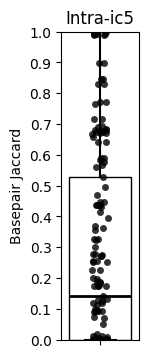

In [72]:
data_df = ic5_max_jaccs_df

plt.figure(figsize=(1, 4))

sns.boxplot(y='BP Jaccard', data=data_df, whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),  # Transparent box
            whiskerprops=dict(color='black', linewidth=1.5),  # Black whiskers
            capprops=dict(color='black', linewidth=1.5),  # Black caps
            medianprops=dict(color='black', linewidth=2),  # Black median line
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0))  # Outliers as black dots

# Add jittered dots (using sns.stripplot)
sns.stripplot(y='BP Jaccard', data=data_df, color='black', alpha=0.8, jitter=True)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.title('Intra-ic5')
plt.xlabel('')
plt.ylabel('Basepair Jaccard')

plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/2935095822.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sample Confidence', y='Jaccard', data=SKBR3_ic5_jaccard_df, palette="Set3", whis=1.5,


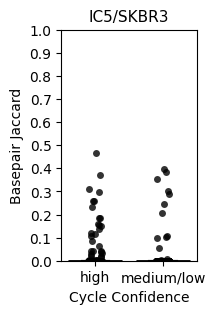

In [73]:
x_order = ['high', 'medium/low']

plt.figure(figsize=(1.75, 3))

sns.boxplot(x='Sample Confidence', y='Jaccard', data=SKBR3_ic5_jaccard_df, palette="Set3", whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
            order=x_order)

sns.stripplot(x='Sample Confidence', y='Jaccard', data=SKBR3_ic5_jaccard_df, color='black', alpha=0.8, jitter=True, order=x_order)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.xlabel("Cycle Confidence")
plt.ylabel('Basepair Jaccard')

plt.title(f'IC5/SKBR3', fontsize=11)

plt.show()

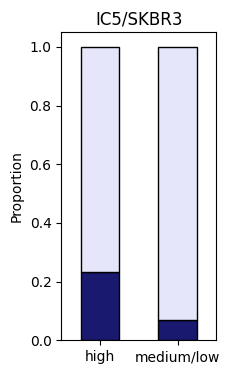

In [74]:
SKBR3_ic5_jaccard_df['Jaccard_Zero'] = (SKBR3_ic5_jaccard_df['Jaccard'] == 0).astype(int)

proportions = SKBR3_ic5_jaccard_df.groupby('Sample Confidence')['Jaccard_Zero'].value_counts(normalize=True).unstack(fill_value=0)

proportions = proportions.loc[x_order]

fig, ax = plt.subplots(figsize=(2, 4))
ax = proportions.plot(kind='bar', stacked=True, color=['midnightblue', 'lavender'], edgecolor='black', ax=ax)

plt.title('IC5/SKBR3')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
ax.legend_.remove()
plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/1067069828.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD12_ic5_jaccard_df, palette="Set3", whis=1.5,


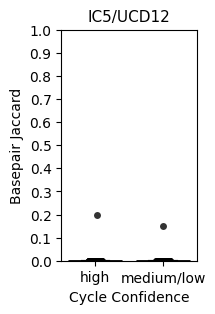

In [75]:
x_order = ['high', 'medium/low']

plt.figure(figsize=(1.75, 3))

sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD12_ic5_jaccard_df, palette="Set3", whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
            order=x_order)

sns.stripplot(x='Sample Confidence', y='Jaccard', data=UCD12_ic5_jaccard_df, color='black', alpha=0.8, jitter=True, order=x_order)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.xlabel("Cycle Confidence")
plt.ylabel('Basepair Jaccard')

plt.title(f'IC5/UCD12', fontsize=11)

plt.show()

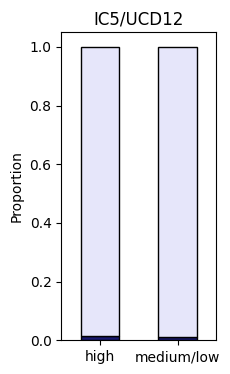

In [76]:
UCD12_ic5_jaccard_df['Jaccard_Zero'] = (UCD12_ic5_jaccard_df['Jaccard'] == 0).astype(int)

proportions = UCD12_ic5_jaccard_df.groupby('Sample Confidence')['Jaccard_Zero'].value_counts(normalize=True).unstack(fill_value=0)

proportions = proportions.loc[x_order]

fig, ax = plt.subplots(figsize=(2, 4))
ax = proportions.plot(kind='bar', stacked=True, color=['midnightblue', 'lavender'], edgecolor='black', ax=ax)

plt.title('IC5/UCD12')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
ax.legend_.remove()
plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/3043581408.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD65_ic5_jaccard_df, palette="Set3", whis=1.5,


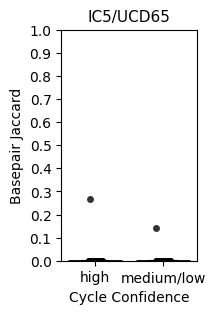

In [77]:
x_order = ['high', 'medium/low']

plt.figure(figsize=(1.75, 3))

sns.boxplot(x='Sample Confidence', y='Jaccard', data=UCD65_ic5_jaccard_df, palette="Set3", whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
            order=x_order)

sns.stripplot(x='Sample Confidence', y='Jaccard', data=UCD65_ic5_jaccard_df, color='black', alpha=0.8, jitter=True, order=x_order)

plt.ylim(0, 1)
plt.yticks([i/10 for i in range(0, 11)])

plt.xlabel("Cycle Confidence")
plt.ylabel('Basepair Jaccard')

plt.title(f'IC5/UCD65', fontsize=11)

plt.show()

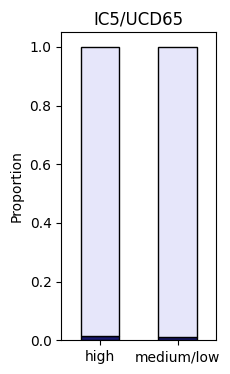

In [78]:
UCD65_ic5_jaccard_df['Jaccard_Zero'] = (UCD65_ic5_jaccard_df['Jaccard'] == 0).astype(int)

proportions = UCD65_ic5_jaccard_df.groupby('Sample Confidence')['Jaccard_Zero'].value_counts(normalize=True).unstack(fill_value=0)

proportions = proportions.loc[x_order]

fig, ax = plt.subplots(figsize=(2, 4))
ax = proportions.plot(kind='bar', stacked=True, color=['midnightblue', 'lavender'], edgecolor='black', ax=ax)

plt.title('IC5/UCD65')
plt.xlabel('')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
ax.legend_.remove()
plt.show()

In [79]:
group1 = ic5_max_jaccs_df['BP Jaccard']
group2 = SKBR3_ic5_jaccard_df[SKBR3_ic5_jaccard_df["Sample Confidence"] == "high"]['Jaccard']
stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
n1 = len(group1)
n2 = len(group2)

# calculate Rank-Biserial correlation for effect size
rank_biserial = (2 * (stat - n1 * n2 / 2)) / (n1 * n2)

print("p = " + str(p_value))
print("RB = " + str(rank_biserial))

p = 2.8627013117771105e-17
RB = 0.5218291475380322


In [80]:
group1 = SKBR3_ic5_jaccard_df[SKBR3_ic5_jaccard_df["Sample Confidence"] == "high"]['Jaccard']
group2 = SKBR3_ic5_jaccard_df[SKBR3_ic5_jaccard_df["Sample Confidence"] == "medium/low"]['Jaccard']
stat, p_value = mannwhitneyu(group1, group2, alternative='greater')
n1 = len(group1)
n2 = len(group2)

# calculate Rank-Biserial correlation for effect size
rank_biserial = (2 * (stat - n1 * n2 / 2)) / (n1 * n2)

print("p = " + str(p_value))
print("RB = " + str(rank_biserial))

p = 3.4748680336682654e-05
RB = 0.15619092627599243


# SUPP. FIG. 8B
## cell line digestion/parental distribution plots

In [81]:
CHR_REGIONS = {'1': (1, 248956422),
               '2': (1, 242193529),
               '3': (1, 198295559),
               '4': (1, 190214555),
               '5': (1, 181538259),
               '6': (1, 170805979),
               '7': (1, 159345973),
               '8': (1, 145138636),
               '9': (1, 138394717),
               '10': (1, 133797422),
               '11': (1, 135086622),
               '12': (1, 133275309),
               '13': (1, 114364328),
               '14': (1, 107043717),
               '15': (1, 101991189),
               '16': (1, 90338345),
               '17': (1, 83257441),
               '18': (1, 80373285),
               '19': (1, 58617616),
               '20': (1, 64444167),
               '21': (1, 46709983),
               '22': (1, 50818468),
               'X': (1, 156040895)}

BIN_SIZE = 50000

In [89]:
# convert info from raw read count file into average coverage depth dictionary
def convert_raw_read_count_file(raw_read_count_file_path):
    avg_coverage_depth_dict = {}
    with open(raw_read_count_file_path, 'r') as file:
        lines = file.readlines()
        for line in lines[1:]:
            fields = line.strip().split("\t")
            chrom = fields[1]
            start = int(fields[2])
            end = int(fields[3])
            avg_coverage = int(fields[4]) * 150/50000
            if chrom not in avg_coverage_depth_dict:
                avg_coverage_depth_dict[chrom] = []
            avg_coverage_depth_dict[chrom].append((start, end, avg_coverage))
    return avg_coverage_depth_dict

# calculate the median coverage over all regions in an average coverage depth dictionary
def get_median_coverage(avg_coverage_depth_dict):
    all_coverage_values = []
    for chrom in avg_coverage_depth_dict:
        regions = avg_coverage_depth_dict[chrom]
        for region in regions:
            all_coverage_values.append(region[2])
    median_coverage = np.median(all_coverage_values)
    return median_coverage

# condense a list of genomic region tuples into non-overlapping regions
def condense_tuples_list(list):
    merged_list = [list[0]]
    for current_region in list[1:]:
        last_region = merged_list[-1]
        if current_region[0] <= last_region[1]:
            merged_list[-1] = (last_region[0], max(last_region[1], current_region[1]))
        else:
            merged_list.append(current_region)
    return merged_list

# get the copy count from a string of information
def parse_copy_count(string, start_indicator, stop_indicator):
    idx1 = string.index(start_indicator) + 1
    idx2 = idx1 + 1
    while (string[idx2] != stop_indicator):
        idx2 += 1
    return int(string[idx1:idx2])

# make a dictionary to store the segments included on each cycle of ecDNA
def get_cycles(file, amplif_threshold=4):
    f = open(file)
    cycles_dict = {}
    for line in f:
        line = line.strip()
        if line[0] == 'C':
            cycle_info = line.split(";")
            copy_ct = parse_copy_count(cycle_info[1], '=', '.')
            if copy_ct >= amplif_threshold:
                cycle_num_idx = cycle_info[0].index('=') + 1
                cycle_num = cycle_info[0][cycle_num_idx:]
                segments_idx = cycle_info[2].index('=') + 1
                segments = cycle_info[2][segments_idx:]
                cycles_dict[cycle_num] = segments
    return cycles_dict

# make a dictionary to store the regions for each ecDNA segment
def get_segments(file):
    f = open(file)
    all_segments_dict = {}
    for line in f:
        line = line.strip()
        if line[0] == "S":
            segment_info = line.split("\t")
            segment_number = segment_info[1]
            segment_chromosome = segment_info[2]
            segment_start = int(segment_info[-2])
            segment_end = int(segment_info[-1])
            all_segments_dict[segment_number] = [segment_chromosome, segment_start, segment_end]
    return all_segments_dict

# extract all ecDNA genomic regions from the cycle file into a dictionary, stored by chromosome
def get_ecDNA_regions_from_cycle_file(cycle_file):
    amplified_cycles_dict = get_cycles(cycle_file)
    amp_cycle_list = []
    for cycle in amplified_cycles_dict:
        cycle_info = amplified_cycles_dict[cycle]
        cycle_info_list = cycle_info.split(',')
        segment_numbers = [segment[:-1] for segment in cycle_info_list]
        for segment in segment_numbers:
            if segment not in amp_cycle_list and segment != '0':
                amp_cycle_list.append(segment)
    segments_dict = get_segments(cycle_file)
    ecDNA_regions_full = {}
    for segment in amp_cycle_list:
        segment_info = segments_dict[segment]
        segment_chrom = segment_info[0][3:]
        if segment_chrom not in ecDNA_regions_full:
            ecDNA_regions_full[segment_chrom] = []
        ecDNA_regions_full[segment_chrom].append((int(segment_info[1]), int(segment_info[2])))
    for chrom in ecDNA_regions_full:
        ecDNA_regions = ecDNA_regions_full[chrom]
        ecDNA_regions_condensed = condense_tuples_list(ecDNA_regions)
        ecDNA_regions_full[chrom] = ecDNA_regions_condensed
    return ecDNA_regions_full

# calculate the length of an ecDNA from its regions dictionary
def get_ecDNA_length_from_regions(ecDNA_regions_dict):
    segment_lengths = []
    for chrom in ecDNA_regions_dict:
        segments = ecDNA_regions_dict[chrom]
        for segment in segments:
            segment_lengths.append(int(segment[1]) - int(segment[0]))
    return segment_lengths

# get the average coverage across a full raw read count file
def get_average_coverage(raw_read_count_file_path):
    total_read_count = 0
    total_length = 0
    with open(raw_read_count_file_path, 'r') as file:
        lines = file.readlines()
        for line in lines[1:]:
            fields = line.strip().split("\t")
            total_read_count += int(fields[4])
            total_length += 50000
    average_coverage = total_read_count * 150 / total_length
    return average_coverage

# get the average coverage across ecDNA intervals
def get_average_coverage_on_ecDNA_intervals(avg_coverage_depth_dict, ecDNA_intervals):

    total_ecDNA_length = 0
    summed_coverage_depth = 0

    for chrom in ecDNA_intervals:
        intervals = ecDNA_intervals[chrom]
        if chrom in avg_coverage_depth_dict:
            for interval in intervals:
                start = interval[0]
                end = interval[1]
                total_ecDNA_length += end - start + 1
                chrom_coverage = avg_coverage_depth_dict[chrom]
                for sample_start, sample_end, sample_avg_coverage in chrom_coverage:
                    # this coverage interval is before the ecDNA interval
                    if sample_end < start:
                        continue
                    # this coverage interval is after the ecDNA interval
                    elif sample_start > end:
                        continue
                    # this coverage interval starts before, but overlaps with, the ecDNA interval
                    elif sample_start <= start <= sample_end:
                        # the end is in the middle of the ecDNA interval
                        if sample_end <= end:
                            summed_coverage_depth += sample_avg_coverage * (sample_end - start + 1)
                        # the end goes beyond the ecDNA interval
                        elif sample_end > end:
                            summed_coverage_depth += sample_avg_coverage * (end - start + 1)
                    # this coverage interval starts after, but overlaps with, the ecDNA interval
                    elif start < sample_start:
                        # the end goes beyond the ecDNA interval
                        if sample_end >= end:
                            summed_coverage_depth += sample_avg_coverage * (end - sample_start + 1)
                        # the end is inside the ecDNA interval
                        elif sample_end < end:
                            summed_coverage_depth += sample_avg_coverage * (sample_end - sample_start + 1)

    average_coverage_depth_on_ecDNA = summed_coverage_depth / total_ecDNA_length

    return average_coverage_depth_on_ecDNA

# get a list of blacklisted regions to exclude from null ecDNA generation
def get_blacklist_regions(chr):
    blacklist_regions = []
    blacklist_file = "full_tool_testing/encode_blacklist_regions.bed"
    with open(blacklist_file, 'r') as file:
        for line in file:
            fields = line.strip().split('\t')
            chrom = fields[0]
            if chrom == 'chr' + str(chr):
                blacklist_regions.append((int(fields[1]), int(fields[2])))
    return blacklist_regions

# get a list of all genomic regions excluding blacklisted regions and the predicted ecDNA regions
def get_valid_genome_regions(chr, full_ecDNA_regions):
    unmappable_regions = get_blacklist_regions(chr)
    if chr in full_ecDNA_regions:
        ecDNA_region = full_ecDNA_regions[chr]
        unmappable_regions.append(ecDNA_region)
        unmappable_regions = sorted(unmappable_regions, key=lambda x: x[0])
        unmappable_regions = condense_tuples_list(unmappable_regions)
    mappable_regions = []
    if unmappable_regions[0][0] != 0:
        unmappable_start = unmappable_regions[0][0]
        mappable_regions.append((0, unmappable_start - 1))
    start = unmappable_regions[0][1] + 1
    for interval in unmappable_regions[1:]:
        end = interval[0] - 1
        mappable_regions.append((start, end))
        start = interval[1] + 1
    if start != CHR_REGIONS[chr][1]:
        mappable_regions.append((start, CHR_REGIONS[chr][1]))
    return mappable_regions

# get a random region of the genome of a given segment length
def get_random_region(genome_regions, segment_length):
    # Calculate the total length of all ranges combined
    total_range_length = sum(end - start + 1 for start, end in genome_regions)

    # Generate a random starting point within the total length
    random_start = random.randint(0, total_range_length - 1)

    # Find the range that contains the random starting point
    for start, end in genome_regions:
        range_length = end - start + 1
        if random_start > range_length:
            random_start -= range_length
        else:
            starting_bp = start + random_start
            if starting_bp + segment_length < end:
                return (starting_bp, starting_bp + segment_length)

    # if you make it here without returning, this has failed to find a region so we try again
    return get_random_region(genome_regions, segment_length)

def sufficient_space_in_chr(segment_len, valid_regions):
    for region in valid_regions:
        region_len = region[1] - region[0]
        if segment_len < region_len:
            return True
    return False

# generate a random null ecDNA with equal length and segmenting to an ecDNA prediction
def generate_null_ecDNA(segment_lengths_list, full_ecDNA_regions):
    null_segments = {}
    for segment_length in segment_lengths_list:
        
        # randomly select a chromosome
        chromosome = str(random.randint(1, 22))
        
        # get the valid genome regions for the chromosome
        valid_genome_regions = get_valid_genome_regions(chromosome, full_ecDNA_regions)
        sufficient_size_region = sufficient_space_in_chr(segment_length, valid_genome_regions)
        
        while not sufficient_size_region:
            chromosome = str(random.randint(1, 22))
            valid_genome_regions = get_valid_genome_regions(chromosome, full_ecDNA_regions)
            sufficient_size_region = sufficient_space_in_chr(segment_length, valid_genome_regions)
        
        # generate ecDNA segments
        null_segment = get_random_region(valid_genome_regions, segment_length)
        if chromosome not in null_segments:
            null_segments[chromosome] = []
        null_segments[chromosome].append(null_segment)
    return null_segments

In [90]:
def get_null_distribution_ratio_vals(sample_raw_read_count_file_digested, sample_raw_read_count_file_parental, comparison_sample_cycle_file, sample_name, full_ecDNA_regions):
    # get digested ACD dict, median coverage for normalization
    avg_coverage_depth_dict_digested = convert_raw_read_count_file(sample_raw_read_count_file_digested)
    median_cov_digested = get_median_coverage(avg_coverage_depth_dict_digested)
    print(median_cov_digested)

    # get parental ACD dict, median coverage for normalization
    avg_coverage_depth_dict_parental = convert_raw_read_count_file(sample_raw_read_count_file_parental)
    median_cov_parental = get_median_coverage(avg_coverage_depth_dict_parental)
    print(median_cov_parental)

    # get predicted ecDNA segments dict
    predicted_ecDNA_segments_dict = get_ecDNA_regions_from_cycle_file(comparison_sample_cycle_file)

    print(predicted_ecDNA_segments_dict)

    # get predicted ACD on ecDNA for digested
    predicted_avg_cov_depth_digested = get_average_coverage_on_ecDNA_intervals(
        avg_coverage_depth_dict_digested,
        predicted_ecDNA_segments_dict) / median_cov_digested

    print(predicted_avg_cov_depth_digested)

    # get predicted ACD on ecDNA for parental
    predicted_avg_cov_depth_parental = get_average_coverage_on_ecDNA_intervals(
        avg_coverage_depth_dict_parental,
        predicted_ecDNA_segments_dict) / median_cov_parental

    print(predicted_avg_cov_depth_parental)

    # calculate predicted ACD ratio
    predicted_avg_cov_depth_ratio = predicted_avg_cov_depth_digested / predicted_avg_cov_depth_parental

    ecDNA_segment_lengths = get_ecDNA_length_from_regions(predicted_ecDNA_segments_dict)

    # start collecting null ACDs
    null_average_coverage_ratios = []

    for i in range(1000):
        null_ecDNA_segments = generate_null_ecDNA(ecDNA_segment_lengths, full_ecDNA_regions)
        average_coverage_digested = get_average_coverage_on_ecDNA_intervals(avg_coverage_depth_dict_digested,
                                                                                      null_ecDNA_segments) / median_cov_digested
        average_coverage_parental = get_average_coverage_on_ecDNA_intervals(avg_coverage_depth_dict_parental,
                                                                                      null_ecDNA_segments) / median_cov_parental
        null_average_coverage_ratios.append(average_coverage_digested / average_coverage_parental)

    p_val = 1 - len([num for num in null_average_coverage_ratios if num < predicted_avg_cov_depth_ratio]) / len(null_average_coverage_ratios)
    print(p_val)
    log_null_average_coverage_ratios = [np.log(value) for value in null_average_coverage_ratios]

    return log_null_average_coverage_ratios, predicted_avg_cov_depth_ratio

In [91]:
UCD12_raw_read_count_file_digested = 'cell_line_validation/UCD12_EC_raw_readcounts.txt'
UCD12_raw_read_count_file_parental = 'cell_line_validation/UCD12_Prt_raw_readcounts.txt'
UCD12_cycle_file = 'cell_line_validation/UCD12_SR_amplicon2_cycles.txt'
UCD12_full_ecDNA_intervals = {'8': (30150001, 42825889), '11': (67048236, 67069082)}

UCD12_log_null_average_coverage_ratios, UCD12_predicted_avg_cov_depth_ratio = get_null_distribution_ratio_vals(UCD12_raw_read_count_file_digested, 
                                                                                                   UCD12_raw_read_count_file_parental, 
                                                                                                   UCD12_cycle_file, 'UCD12', 
                                                                                                   UCD12_full_ecDNA_intervals)

0.843
0.126
{'8': [(37194335, 39178861), (39381036, 39827399)]}
6.367974500031417
1.3088808745827099
0.0


/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/558216423.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


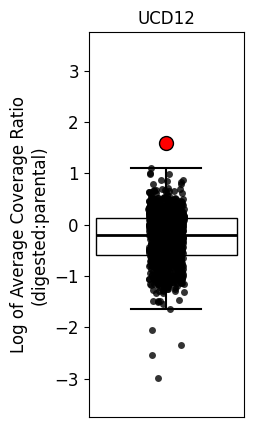

In [92]:
plt.figure(figsize=(2, 5))

sns.boxplot(
    y=UCD12_log_null_average_coverage_ratios, color='black', palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    y=UCD12_log_null_average_coverage_ratios, color='black', alpha=0.8, jitter=True
)

plt.scatter(0, np.log(UCD12_predicted_avg_cov_depth_ratio), color='red', s=100, edgecolor='black', zorder=3)

plt.ylabel('Log of Average Coverage Ratio\n(digested:parental)', fontsize=12)
plt.xticks([])
plt.ylim(-3.75, 3.75)
plt.yticks(fontsize=12)
plt.title('UCD12', fontsize=12)

plt.show()

In [93]:
UCD65_raw_read_count_file_digested = 'cell_line_validation/UCD65_EC_raw_readcounts.txt'
UCD65_raw_read_count_file_parental = 'cell_line_validation/UCD65_Prt_raw_readcounts.txt'
UCD65_cycle_file = 'cell_line_validation/UCD65_SR_amplicon1_cycles.txt'
UCD65_full_ecDNA_intervals = {'8': (35150001, 42223758), '12': (122300001, 124400000), '17': (27600001, 74490000),
                              '19': (5684617, 7550000), '20': (57396374, 57417204)}

UCD65_log_null_average_coverage_ratios, UCD65_predicted_avg_cov_depth_ratio = get_null_distribution_ratio_vals(UCD65_raw_read_count_file_digested, 
                                                                                                   UCD65_raw_read_count_file_parental, 
                                                                                                   UCD65_cycle_file, 'UCD65', 
                                                                                                   UCD65_full_ecDNA_intervals)

1.227
0.12
{'19': [(6918769, 7437298)], '8': [(38925228, 39374554), (39529709, 39822519), (39846300, 40001793), (40096921, 40167267), (40170384, 40172604)]}
25.459285920621173
0.8830637691186446
0.0


/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_44808/2423323311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


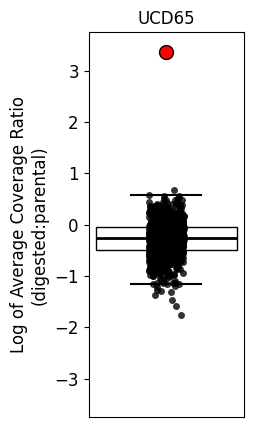

In [94]:
plt.figure(figsize=(2, 5))

sns.boxplot(
    y=UCD65_log_null_average_coverage_ratios, color='black', palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    y=UCD65_log_null_average_coverage_ratios, color='black', alpha=0.8, jitter=True
)

plt.scatter(0, np.log(UCD65_predicted_avg_cov_depth_ratio), color='red', s=100, edgecolor='black', zorder=3)

plt.ylabel('Log of Average Coverage Ratio\n(digested:parental)', fontsize=12)
plt.xticks([])
plt.ylim(-3.75, 3.75)
plt.yticks(fontsize=12)
plt.title('UCD65', fontsize=12)

plt.show()